h = 0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Solution may not be Entirely Stable ;)

h = 0.1
Eigenvalues: [1.+0.1j 1.-0.1j]
Solution may not be Entirely Stable ;)

h = 0.5
Eigenvalues: [1.+0.5j 1.-0.5j]
Solution may not be Entirely Stable ;)

h = 1.0
Eigenvalues: [1.+1.j 1.-1.j]
Solution may not be Entirely Stable ;)



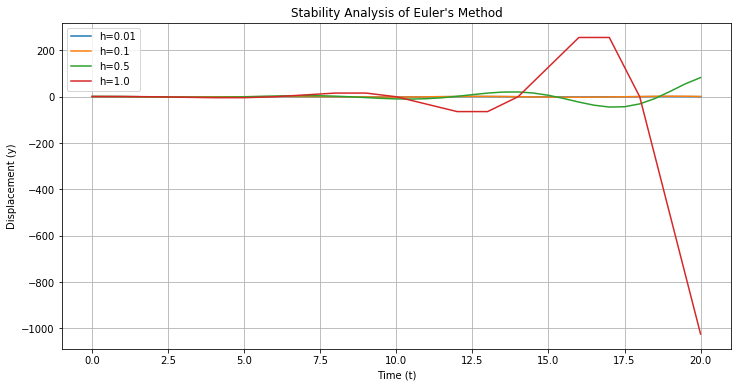

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Given set parameters
k = 1.0
h_values = [0.01, 0.1, 0.5, 1.0]
t_start = 0
t_end = 20
y_0 = 1.0
v_0 = 0.0

# Euler method implemented
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return t_values, y_values


# Plotting
plt.figure(figsize=(12, 6))

for h in h_values:

    # matrix for steps
    A = np.array([[1, h],
                  [-h * k, 1]])

    # Taking the eigenvalues
    eigenvalues = np.linalg.eigvals(A)

    print(f"h = {h}")
    print(f"Eigenvalues: {eigenvalues}")

    # Stability analysis implemented with chat GPT
    if np.all(np.abs(eigenvalues) < 1):
        print("Solution is Stable\n")
    else:
        print("Solution may not be Entirely Stable ;)\n")

    # Solving function
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f"h={h}")

plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title("Stability Analysis of Euler's Method")
plt.legend()
plt.grid(True)
plt.show()